# Probability and Distributions for Deep Learning

**Why this notebook exists:** Every DL concept with "probabilistic" or "stochastic" in its name comes from here. Loss functions are log-likelihoods. Regularization is a prior. VAEs are posterior inference. Dropout is a Bernoulli sample. GANs compare distributions. Without probability, you can use these tools but you cannot understand or improve them.

**What you will be able to do after this notebook:**
- Understand why cross-entropy loss = negative log-likelihood
- Understand KL divergence and why it appears in VAEs
- Derive the reparameterization trick from first principles
- Understand what a model is actually learning (a probability distribution)
- Read the math in papers that use ∝, 𝔼, KL, and 𝒩

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/00_math/probability_distributions.ipynb)

---

## Table of Contents
1. [Probability Fundamentals](#1-probability-fundamentals)
2. [Key Distributions in DL](#2-key-distributions)
3. [Expectation and Variance](#3-expectation-and-variance)
4. [Maximum Likelihood Estimation — where loss functions come from](#4-maximum-likelihood-estimation)
5. [Information Theory — Entropy, Cross-Entropy, KL Divergence](#5-information-theory)
6. [Bayes Theorem and Probabilistic Models](#6-bayes-theorem)
7. [Monte Carlo Estimation and the Reparameterization Trick](#7-monte-carlo-and-reparameterization)
8. [How Probability Shows Up in DL](#8-probability-in-dl)
9. [Visual Intuition](#9-visual-intuition)
10. [Exercises](#10-exercises)


## Setup

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

print('NumPy:', np.__version__)


NumPy: 2.0.2


## 1. Probability Fundamentals

### Random Variables

A **random variable** $X$ is a variable whose value is determined by a random process. We describe its behaviour with a probability distribution.

- **Discrete** $X$: $P(X = x)$ — probability mass function (PMF)
- **Continuous** $X$: $p(x)$ — probability density function (PDF), where $P(a \leq X \leq b) = \int_a^b p(x)\, dx$

### Essential Rules

**Sum rule (marginalisation):**
$$P(X) = \sum_Y P(X, Y) \quad \text{(discrete)} \qquad p(x) = \int p(x, y)\, dy \quad \text{(continuous)}$$

**Product rule:**
$$P(X, Y) = P(X \mid Y)\, P(Y) = P(Y \mid X)\, P(X)$$

**Bayes' theorem** (derived from product rule):
$$P(Y \mid X) = \frac{P(X \mid Y)\, P(Y)}{P(X)}$$

**Independence:** $X \perp Y$ if and only if $P(X, Y) = P(X)\, P(Y)$

### The DL Lens

| Concept | DL meaning |
|---|---|
| $P(y \mid x; \theta)$ | Model's predicted probability of label $y$ given input $x$ and weights $\theta$ |
| $P(\theta)$ | Prior belief about weights (L2 reg = Gaussian prior, L1 = Laplace prior) |
| $P(\theta \mid \mathcal{D})$ | Posterior — updated belief after seeing data |
| $P(y \mid x)$ | What the model is trying to learn |


In [16]:
# Discrete probability — coin flip and dice
print('=== Discrete distributions ===')

# Fair coin
coin_pmf = {'H': 0.5, 'T': 0.5}
print(f'Fair coin PMF: {coin_pmf}')
print(f'Sum of probabilities: {sum(coin_pmf.values())} (must equal 1)')

# Biased die
die_faces  = np.arange(1, 7)
die_probs  = np.array([0.1, 0.1, 0.2, 0.2, 0.2, 0.2])
print(f'\nBiased die PMF: {dict(zip(die_faces, die_probs))}')
print(f'Sum: {die_probs.sum()}')

# Simulate
n_rolls   = 100_000
simulated = rng.choice(die_faces, size=n_rolls, p=die_probs)
emp_probs = np.bincount(simulated)[1:] / n_rolls

print('\nEmpirical vs theoretical (100k samples):')
print(f'  Face:        {die_faces}')
print(f'  Theoretical: {die_probs}')
print(f'  Empirical:   {emp_probs}')


=== Discrete distributions ===
Fair coin PMF: {'H': 0.5, 'T': 0.5}
Sum of probabilities: 1.0 (must equal 1)

Biased die PMF: {np.int64(1): np.float64(0.1), np.int64(2): np.float64(0.1), np.int64(3): np.float64(0.2), np.int64(4): np.float64(0.2), np.int64(5): np.float64(0.2), np.int64(6): np.float64(0.2)}
Sum: 1.0

Empirical vs theoretical (100k samples):
  Face:        [1 2 3 4 5 6]
  Theoretical: [0.1 0.1 0.2 0.2 0.2 0.2]
  Empirical:   [0.0992 0.1001 0.1986 0.2006 0.2024 0.1992]


In [17]:
# Continuous probability — PDF and CDF
print('=== Continuous distributions ===')

x = np.linspace(-4, 4, 1000)
mu, sigma = 0.0, 1.0

# Standard Normal PDF: p(x) = (1/sqrt(2π)) * exp(-x²/2)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)
cdf = stats.norm.cdf(x, mu, sigma)

# Verify PDF integrates to 1
dx         = x[1] - x[0]
integral   = np.sum(pdf) * dx
print(f'Integral of N(0,1) PDF over [-4,4]: {integral:.6f} (should be ≈ 1)')

# P(a < X < b)
a, b = -1.0, 1.0
prob_1sigma = np.sum(pdf[(x >= a) & (x <= b)]) * dx
print(f'P(-1 < X < 1) = {prob_1sigma:.4f}  (68.27% rule)')
print(f'P(-2 < X < 2) = {np.sum(pdf[(x>=-2)&(x<=2)])*dx:.4f}  (95.45% rule)')
print(f'P(-3 < X < 3) = {np.sum(pdf[(x>=-3)&(x<=3)])*dx:.4f}  (99.73% rule)')


=== Continuous distributions ===
Integral of N(0,1) PDF over [-4,4]: 0.999938 (should be ≈ 1)
P(-1 < X < 1) = 0.6832  (68.27% rule)
P(-2 < X < 2) = 0.9547  (95.45% rule)
P(-3 < X < 3) = 0.9973  (99.73% rule)


## 2. Key Distributions in Deep Learning

### Bernoulli Distribution

A single binary outcome (0 or 1) with probability $p$:

$$P(X = x) = p^x (1-p)^{1-x}, \quad x \in \{0, 1\}$$

**In DL:** Binary classification output. Dropout (each neuron kept with probability $1-p$). The logistic regression output models $P(y=1 \mid x)$ as a Bernoulli distribution.

### Categorical Distribution

Generalises Bernoulli to $K$ outcomes:

$$P(X = k) = p_k, \quad \sum_k p_k = 1$$

**In DL:** Multi-class classification. The softmax output models $P(y = k \mid x)$ as a Categorical distribution. Cross-entropy loss is the negative log-likelihood of this distribution.

### Gaussian (Normal) Distribution

$$\mathcal{N}(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**In DL:**
- Weight initialisation assumes near-Gaussian pre-activations (Xavier/He init)
- L2 regularisation = Gaussian prior on weights (MAP estimation)
- VAE latent space: $z \sim \mathcal{N}(0, I)$ (standard normal prior)
- BatchNorm normalises to approximate $\mathcal{N}(0, 1)$
- Gaussian noise in diffusion models

### Multivariate Gaussian

$$\mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \Sigma) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$

The **covariance matrix** $\Sigma_{ij} = \text{Cov}(X_i, X_j)$ captures how features co-vary. PCA diagonalises $\Sigma$ — the eigenvectors are the principal components.

### Uniform Distribution

$$\mathcal{U}(a, b): \quad p(x) = \frac{1}{b-a} \text{ for } x \in [a, b]$$

**In DL:** Xavier initialisation samples from $\mathcal{U}\left(-\frac{1}{\sqrt{n}}, \frac{1}{\sqrt{n}}\right)$.


/tmp/ipykernel_10561/3896132290.py:70: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_10561/3896132290.py:70: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


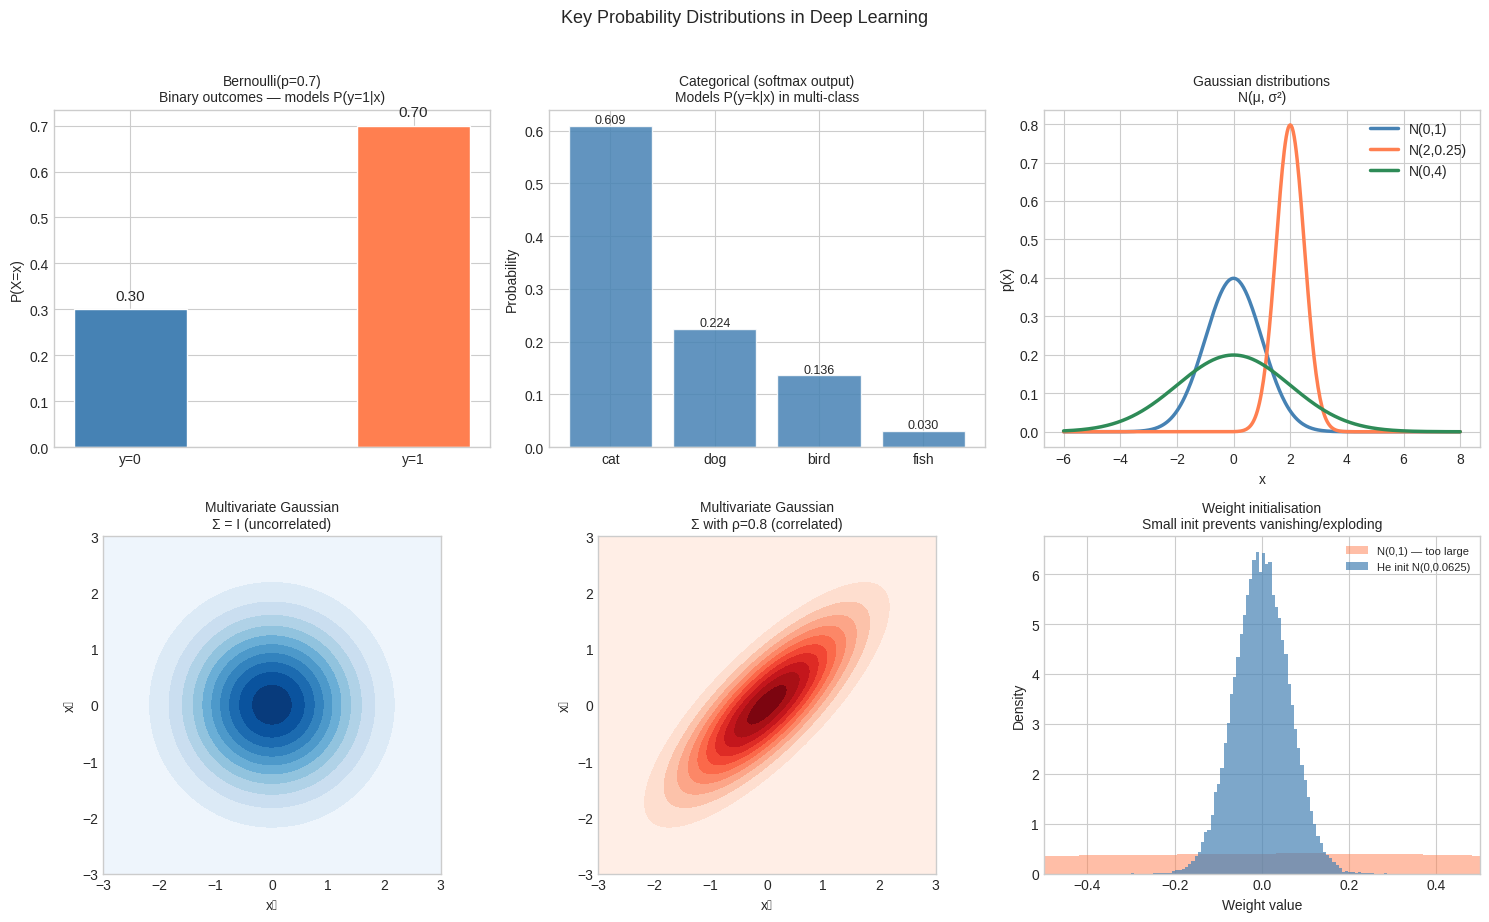

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Bernoulli
p_bern = 0.7
axes[0,0].bar([0, 1], [1-p_bern, p_bern], color=['steelblue','coral'],
              edgecolor='white', width=0.4)
axes[0,0].set_title(f'Bernoulli(p={p_bern})\nBinary outcomes — models P(y=1|x)', fontsize=10)
axes[0,0].set_xticks([0, 1]); axes[0,0].set_xticklabels(['y=0', 'y=1'])
axes[0,0].set_ylabel('P(X=x)')
for x_val, h in [(0, 1-p_bern), (1, p_bern)]:
    axes[0,0].text(x_val, h+0.02, f'{h:.2f}', ha='center', fontsize=11)

# 2. Categorical (softmax output)
classes = ['cat', 'dog', 'bird', 'fish']
logits  = np.array([2.0, 1.0, 0.5, -1.0])
probs   = np.exp(logits) / np.exp(logits).sum()
axes[0,1].bar(classes, probs, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Categorical (softmax output)\nModels P(y=k|x) in multi-class', fontsize=10)
axes[0,1].set_ylabel('Probability')
for i, p in enumerate(probs):
    axes[0,1].text(i, p+0.005, f'{p:.3f}', ha='center', fontsize=9)

# 3. Gaussian — different μ and σ
x_g = np.linspace(-6, 8, 400)
params = [(0, 1, 'steelblue', 'N(0,1)'),
          (2, 0.5, 'coral', 'N(2,0.25)'),
          (0, 2, 'seagreen', 'N(0,4)')]
for mu_, sigma_, color, label in params:
    pdf_ = stats.norm.pdf(x_g, mu_, sigma_)
    axes[0,2].plot(x_g, pdf_, color=color, linewidth=2.5, label=label)
axes[0,2].set_title('Gaussian distributions\nN(μ, σ²)', fontsize=10)
axes[0,2].legend(); axes[0,2].set_xlabel('x'); axes[0,2].set_ylabel('p(x)')

# 4. Multivariate Gaussian — correlated vs uncorrelated
from matplotlib.patches import Ellipse
x1_r = np.linspace(-3, 3, 100)
x2_r = np.linspace(-3, 3, 100)
X1_r, X2_r = np.meshgrid(x1_r, x2_r)
pos = np.dstack((X1_r, X2_r))

rv_uncorr = stats.multivariate_normal([0,0], [[1,0],[0,1]])
rv_corr   = stats.multivariate_normal([0,0], [[1,0.8],[0.8,1]])

axes[1,0].contourf(X1_r, X2_r, rv_uncorr.pdf(pos), levels=10, cmap='Blues')
axes[1,0].set_title('Multivariate Gaussian\nΣ = I (uncorrelated)', fontsize=10)
axes[1,0].set_xlabel('x₁'); axes[1,0].set_ylabel('x₂')
axes[1,0].set_aspect('equal')

axes[1,1].contourf(X1_r, X2_r, rv_corr.pdf(pos), levels=10, cmap='Reds')
axes[1,1].set_title('Multivariate Gaussian\nΣ with ρ=0.8 (correlated)', fontsize=10)
axes[1,1].set_xlabel('x₁'); axes[1,1].set_ylabel('x₂')
axes[1,1].set_aspect('equal')

# 5. Weight initialisation distributions
n_in = 512
glorot_std = np.sqrt(2.0 / n_in)
he_std     = np.sqrt(2.0 / n_in)

w_glorot = rng.normal(0, glorot_std, 50_000)
w_he     = rng.normal(0, he_std,     50_000)
w_bad    = rng.normal(0, 1.0,        50_000)  # too large!

axes[1,2].hist(w_bad,    bins=80, alpha=0.5, color='coral',     density=True, label='N(0,1) — too large')
axes[1,2].hist(w_glorot, bins=80, alpha=0.7, color='steelblue', density=True, label=f'He init N(0,{he_std:.4f})')
axes[1,2].set_title('Weight initialisation\nSmall init prevents vanishing/exploding', fontsize=10)
axes[1,2].set_xlabel('Weight value'); axes[1,2].set_ylabel('Density')
axes[1,2].set_xlim(-0.5, 0.5); axes[1,2].legend(fontsize=8)

plt.suptitle('Key Probability Distributions in Deep Learning', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3. Expectation and Variance

### Expectation (Expected Value)

The **expected value** or **mean** of a random variable:

$$\mathbb{E}[X] = \sum_x x \, P(X=x) \quad \text{(discrete)} \qquad \mathbb{E}[X] = \int x \, p(x) \, dx \quad \text{(continuous)}$$

**Key properties:**
- Linearity: $\mathbb{E}[aX + bY] = a\mathbb{E}[X] + b\mathbb{E}[Y]$
- For independent $X, Y$: $\mathbb{E}[XY] = \mathbb{E}[X]\mathbb{E}[Y]$

**In DL:** The training loss $\mathcal{L} = \frac{1}{m}\sum_i L(x_i, y_i)$ is the **empirical expectation** of the loss under the data distribution:
$$\mathcal{L}(\theta) = \mathbb{E}_{(x,y) \sim \mathcal{D}}[L(f_\theta(x), y)]$$

### Variance and Standard Deviation

$$\text{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

$$\text{Std}(X) = \sqrt{\text{Var}(X)}$$

**In DL:**
- BatchNorm normalises activations to $\mu=0$, $\sigma^2=1$
- He initialisation sets $\text{Var}(W) = 2/n_{\text{in}}$ so pre-activations have unit variance
- Gradient variance determines training stability

### Covariance and Correlation

$$\text{Cov}(X, Y) = \mathbb{E}[(X - \mu_X)(Y - \mu_Y)] = \mathbb{E}[XY] - \mu_X \mu_Y$$

$$\text{Corr}(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y} \in [-1, 1]$$

Covariance matrix: $\Sigma = \mathbb{E}[(\mathbf{x}-\boldsymbol{\mu})(\mathbf{x}-\boldsymbol{\mu})^T]$. This is exactly what PCA diagonalises.


=== Why He initialisation works ===

Consider a layer: z = Wx where x ~ N(0, 1), W ~ N(0, σ²_w)
z_j = Σ_i W_ji * x_i  (sum of n_in independent products)

Var(W_ji * x_i) = Var(W_ji) * Var(x_i) = σ²_w * 1 = σ²_w
Var(z_j) = n_in * σ²_w  (variance adds for independent terms)

For Var(z_j) = 1 (preserve signal scale): σ²_w = 1/n_in
He initialisation (with ReLU): σ²_w = 2/n_in  (factor 2 for ReLU halving variance)


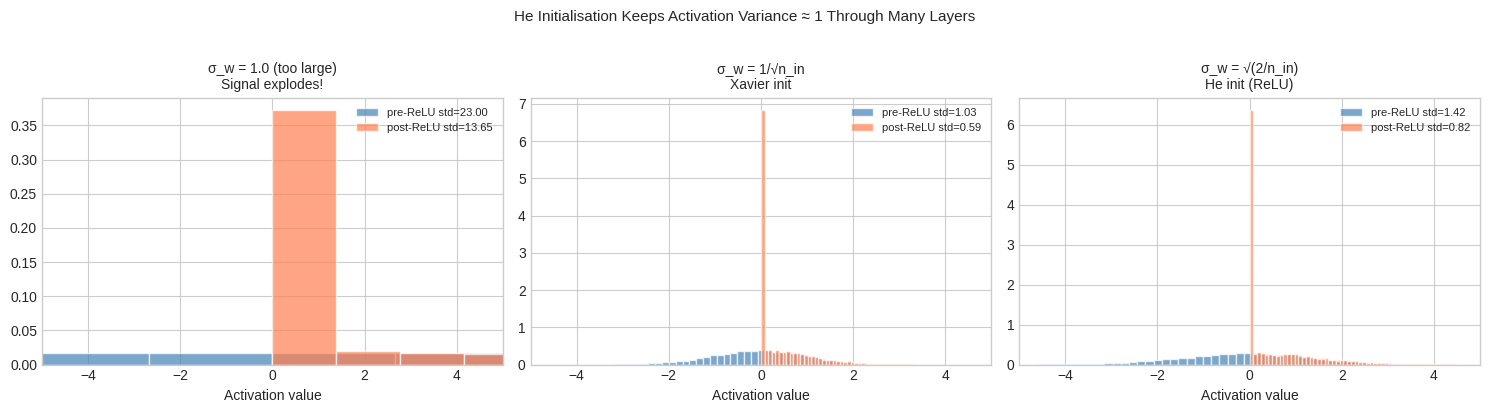

In [19]:
# Demonstrate He initialisation variance analysis
print('=== Why He initialisation works ===')
print()
print('Consider a layer: z = Wx where x ~ N(0, 1), W ~ N(0, σ²_w)')
print('z_j = Σ_i W_ji * x_i  (sum of n_in independent products)')
print()
print('Var(W_ji * x_i) = Var(W_ji) * Var(x_i) = σ²_w * 1 = σ²_w')
print('Var(z_j) = n_in * σ²_w  (variance adds for independent terms)')
print()
print('For Var(z_j) = 1 (preserve signal scale): σ²_w = 1/n_in')
print('He initialisation (with ReLU): σ²_w = 2/n_in  (factor 2 for ReLU halving variance)')

# Verify experimentally
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

n_in = 512
n_samples = 10_000

for ax, sigma_w, title in zip(axes,
    [1.0, np.sqrt(1.0/n_in), np.sqrt(2.0/n_in)],
    ['σ_w = 1.0 (too large)\nSignal explodes!',
     f'σ_w = 1/√n_in\nXavier init',
     f'σ_w = √(2/n_in)\nHe init (ReLU)']):

    x_sim = rng.normal(0, 1, (n_in, n_samples))
    W_sim = rng.normal(0, sigma_w, (1, n_in))
    z_sim = W_sim @ x_sim   # (1, n_samples)
    z_sim_relu = np.maximum(0, z_sim)  # after ReLU

    ax.hist(z_sim.ravel(), bins=60, color='steelblue', alpha=0.7,
            density=True, edgecolor='white', label=f'pre-ReLU std={z_sim.std():.2f}')
    ax.hist(z_sim_relu.ravel(), bins=60, color='coral', alpha=0.7,
            density=True, edgecolor='white', label=f'post-ReLU std={z_sim_relu.std():.2f}')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Activation value'); ax.legend(fontsize=8)
    ax.set_xlim(-5, 5)

plt.suptitle('He Initialisation Keeps Activation Variance ≈ 1 Through Many Layers',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 4. Maximum Likelihood Estimation — Where Loss Functions Come From

**MLE** finds the parameters $\theta$ that maximise the probability of observing the training data:

$$\hat{\theta}_{\text{MLE}} = \arg\max_\theta \prod_{i=1}^m P(y_i \mid x_i; \theta)$$

Taking the log (log is monotone, so argmax is unchanged):

$$\hat{\theta}_{\text{MLE}} = \arg\max_\theta \sum_{i=1}^m \log P(y_i \mid x_i; \theta)$$

Negating to convert to minimisation:

$$\hat{\theta}_{\text{MLE}} = \arg\min_\theta -\frac{1}{m}\sum_{i=1}^m \log P(y_i \mid x_i; \theta)$$

This is the **negative log-likelihood (NLL)** — and it equals our standard loss functions:

### Case 1: Regression → MSE Loss

Assume $y_i = f_\theta(x_i) + \epsilon$ where $\epsilon \sim \mathcal{N}(0, \sigma^2)$. Then:

$$P(y_i \mid x_i; \theta) = \mathcal{N}(y_i; f_\theta(x_i), \sigma^2)$$

$$\log P(y_i \mid x_i; \theta) = -\frac{1}{2\sigma^2}(y_i - f_\theta(x_i))^2 + \text{const}$$

$$\Rightarrow \arg\min_\theta \text{NLL} = \arg\min_\theta \sum_i (y_i - f_\theta(x_i))^2 = \text{MSE}$$

**MSE is MLE under a Gaussian noise assumption.**

### Case 2: Classification → Cross-Entropy Loss

Assume $P(y_i = k \mid x_i; \theta) = \text{softmax}(f_\theta(x_i))_k$. Then:

$$\log P(y_i \mid x_i; \theta) = \log p_{y_i} = \sum_k \mathbb{1}[y_i = k] \log p_k$$

$$\Rightarrow \text{NLL} = -\frac{1}{m}\sum_i \sum_k \mathbb{1}[y_i=k] \log p_k = \text{Cross-Entropy}$$

**Cross-entropy loss is MLE under a Categorical distribution assumption.**

### MAP Estimation — Adding Regularisation

**Maximum A Posteriori (MAP)** adds a prior $P(\theta)$ on the weights:

$$\hat{\theta}_{\text{MAP}} = \arg\max_\theta \log P(\theta \mid \mathcal{D}) = \arg\max_\theta \left[\log P(\mathcal{D} \mid \theta) + \log P(\theta)\right]$$

- Gaussian prior $P(\theta) \propto \exp(-\lambda\|\theta\|^2_2)$ → L2 regularisation (Ridge)
- Laplace prior $P(\theta) \propto \exp(-\lambda\|\theta\|_1)$ → L1 regularisation (Lasso)

**Regularisation is Bayesian inference with a prior over weights.**


=== MSE as Maximum Likelihood ===


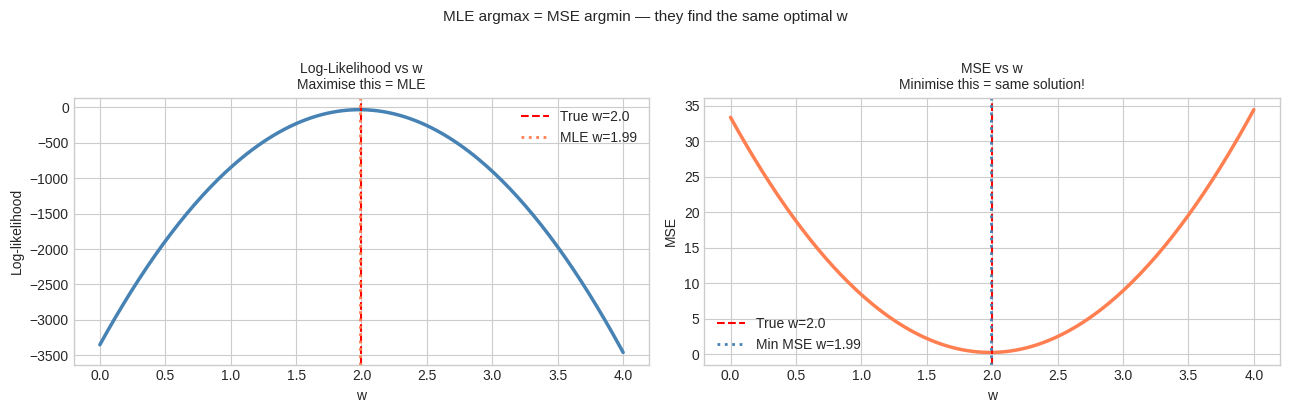

MLE best w:     1.9899
Min MSE best w: 1.9899
True w:         2.0


In [20]:
# Demonstrate: MSE = MLE under Gaussian noise
print('=== MSE as Maximum Likelihood ===')

# Generate data from y = 2x + 1 + noise
true_w, true_b = 2.0, 1.0
x_data = np.linspace(0, 5, 50)
noise  = rng.normal(0, 0.5, 50)
y_data = true_w * x_data + true_b + noise

# Try different w values and compute both log-likelihood and MSE
w_range = np.linspace(0, 4, 200)
sigma   = 0.5   # known noise std

log_likes = []
mse_vals  = []

for w in w_range:
    y_pred   = w * x_data + true_b
    residuals= y_data - y_pred
    # Log-likelihood: sum of log N(residual; 0, sigma^2)
    log_like = -0.5 * np.sum(residuals**2) / sigma**2 - len(x_data)*np.log(sigma*np.sqrt(2*np.pi))
    mse      = np.mean(residuals**2)
    log_likes.append(log_like)
    mse_vals.append(mse)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(w_range, log_likes, color='steelblue', linewidth=2.5)
axes[0].axvline(true_w, color='red', linestyle='--', linewidth=1.5, label=f'True w={true_w}')
axes[0].axvline(w_range[np.argmax(log_likes)], color='coral', linestyle=':', linewidth=2,
                label=f'MLE w={w_range[np.argmax(log_likes)]:.2f}')
axes[0].set_title('Log-Likelihood vs w\nMaximise this = MLE', fontsize=10)
axes[0].set_xlabel('w'); axes[0].set_ylabel('Log-likelihood')
axes[0].legend()

axes[1].plot(w_range, mse_vals, color='coral', linewidth=2.5)
axes[1].axvline(true_w, color='red', linestyle='--', linewidth=1.5, label=f'True w={true_w}')
axes[1].axvline(w_range[np.argmin(mse_vals)], color='steelblue', linestyle=':', linewidth=2,
                label=f'Min MSE w={w_range[np.argmin(mse_vals)]:.2f}')
axes[1].set_title('MSE vs w\nMinimise this = same solution!', fontsize=10)
axes[1].set_xlabel('w'); axes[1].set_ylabel('MSE')
axes[1].legend()

plt.suptitle('MLE argmax = MSE argmin — they find the same optimal w', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'MLE best w:     {w_range[np.argmax(log_likes)]:.4f}')
print(f'Min MSE best w: {w_range[np.argmin(mse_vals)]:.4f}')
print(f'True w:         {true_w}')


## 5. Information Theory — Entropy, Cross-Entropy, KL Divergence

### Entropy

Entropy measures the **average amount of information** (uncertainty) in a distribution:

$$H(P) = -\sum_x P(x) \log P(x) = \mathbb{E}_P[-\log P(x)]$$

- $H = 0$: no uncertainty (all probability on one outcome)
- $H = \log K$: maximum uncertainty (uniform over $K$ outcomes)
- Units: bits (log base 2) or nats (natural log) — DL uses nats

**In DL:** Decision tree splits maximise information gain (reduce entropy).

### Cross-Entropy

Cross-entropy measures the **average code length** when using distribution $Q$ to encode samples from $P$:

$$H(P, Q) = -\sum_x P(x) \log Q(x) = \mathbb{E}_P[-\log Q(x)]$$

In classification: $P$ = true labels (one-hot), $Q$ = model probabilities:

$$\mathcal{L}_{CE} = -\sum_k P_k \log Q_k = -\log Q_{y_{\text{true}}} \quad \text{(since P is one-hot)}$$

This is exactly `nn.CrossEntropyLoss` in PyTorch.

### KL Divergence

KL divergence measures how much distribution $Q$ differs from reference distribution $P$:

$$D_{\text{KL}}(P \| Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)} = \mathbb{E}_P\left[\log\frac{P(x)}{Q(x)}\right]$$

**Key properties:**
- $D_{\text{KL}}(P \| Q) \geq 0$ always — equals 0 if and only if $P = Q$
- **Asymmetric:** $D_{\text{KL}}(P \| Q) \neq D_{\text{KL}}(Q \| P)$
- Not a true distance metric

**Relationship:** $H(P, Q) = H(P) + D_{\text{KL}}(P \| Q)$

Minimising cross-entropy = minimising KL divergence (since $H(P)$ is fixed).

**In DL:**
- VAE objective: $D_{\text{KL}}(q_\phi(z|x) \| p(z))$ — forces encoder to stay close to prior
- Knowledge distillation: $D_{\text{KL}}(P_{\text{teacher}} \| P_{\text{student}})$
- Policy gradient (RL): KL constraint between old and new policy


In [21]:
# Entropy and KL divergence — numerical examples
def entropy(p, eps=1e-12):
    p = np.array(p)
    p = p / p.sum()
    return -np.sum(p * np.log(p + eps))

def cross_entropy(p, q, eps=1e-12):
    p, q = np.array(p), np.array(q)
    p, q = p / p.sum(), q / q.sum()
    return -np.sum(p * np.log(q + eps))

def kl_divergence(p, q, eps=1e-12):
    p, q = np.array(p), np.array(q)
    p, q = p / p.sum(), q / q.sum()
    return np.sum(p * np.log((p + eps) / (q + eps)))

# Example distributions over 4 classes
P_true  = np.array([1.0, 0.0, 0.0, 0.0])   # one-hot true label
Q_good  = np.array([0.9, 0.05, 0.03, 0.02]) # confident correct
Q_bad   = np.array([0.1, 0.3, 0.3, 0.3])   # confident wrong
Q_uniform = np.array([0.25, 0.25, 0.25, 0.25])

print(f'{'Distribution':<20}  {'H(P,Q)':>10}  {'KL(P||Q)':>10}  {'H(P)':>8}')
print('-' * 55)
H_p = entropy(P_true)
for name, Q in [('Q_good', Q_good), ('Q_bad', Q_bad), ('Q_uniform', Q_uniform)]:
    ce = cross_entropy(P_true, Q)
    kl = kl_divergence(P_true, Q)
    print(f'{name:<20}  {ce:10.4f}  {kl:10.4f}  {H_p:8.4f}')

print(f'\nNote: H(P,Q) = H(P) + KL(P||Q) = {H_p:.4f} + KL')
print('Lower cross-entropy = closer Q to P = better model predictions')


Distribution              H(P,Q)    KL(P||Q)      H(P)
-------------------------------------------------------
Q_good                    0.1054      0.1054   -0.0000
Q_bad                     2.3026      2.3026   -0.0000
Q_uniform                 1.3863      1.3863   -0.0000

Note: H(P,Q) = H(P) + KL(P||Q) = -0.0000 + KL
Lower cross-entropy = closer Q to P = better model predictions


=== KL divergence between Gaussians ===

KL(N(μ,σ²) || N(0,1)) = ½(σ² + μ² - 1 - log σ²)

This is the VAE regularisation term.
It measures how far the encoder posterior is from the standard normal prior.


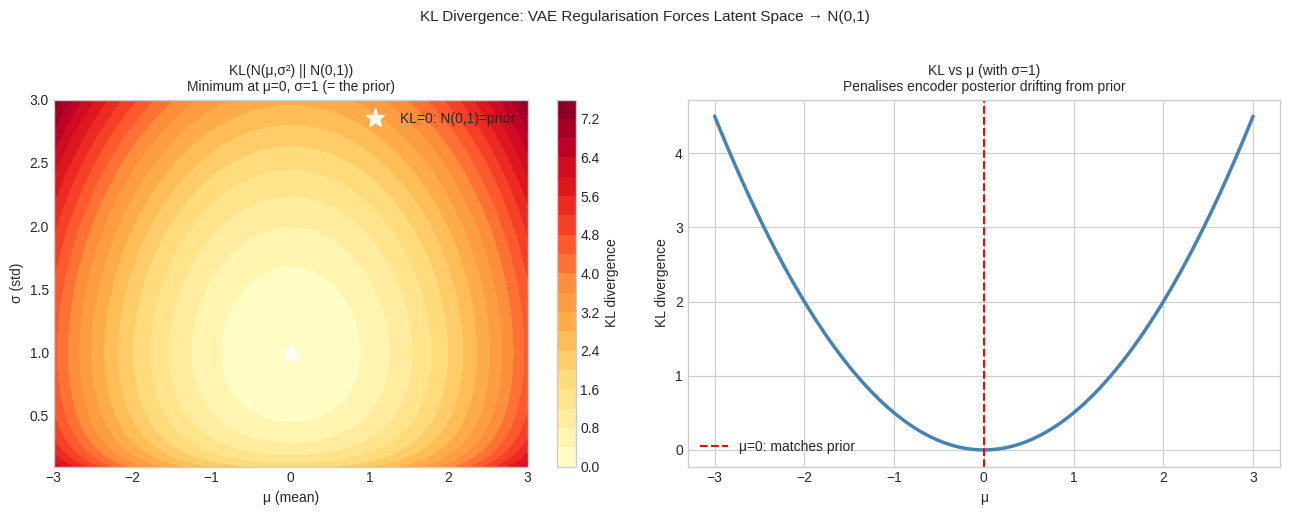

KL(N(μ,σ²) || N(0,1)) examples:
  μ=+0.0, σ²=1.00  ->  KL=0.0000
  μ=+1.0, σ²=1.00  ->  KL=0.5000
  μ=+0.0, σ²=4.00  ->  KL=0.8069
  μ=+2.0, σ²=0.50  ->  KL=2.0966


In [22]:
# KL divergence between two Gaussians — closed form used in VAE
print('=== KL divergence between Gaussians ===')
print()
print('KL(N(μ,σ²) || N(0,1)) = ½(σ² + μ² - 1 - log σ²)')
print()
print('This is the VAE regularisation term.')
print('It measures how far the encoder posterior is from the standard normal prior.')

def kl_gaussian_to_standard_normal(mu, log_var):
    # KL(N(mu, sigma^2) || N(0, 1))
    # = 0.5 * (sigma^2 + mu^2 - 1 - log(sigma^2))
    return 0.5 * (np.exp(log_var) + mu**2 - 1 - log_var)

# Visualize KL as function of mu and sigma
mu_range  = np.linspace(-3, 3, 100)
sig_range = np.linspace(0.1, 3, 100)
MU, SIG   = np.meshgrid(mu_range, sig_range)
LOG_VAR   = np.log(SIG**2)
KL_MAP    = kl_gaussian_to_standard_normal(MU, LOG_VAR)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cp = axes[0].contourf(MU, SIG, KL_MAP, levels=20, cmap='YlOrRd')
plt.colorbar(cp, ax=axes[0], label='KL divergence')
axes[0].plot(0, 1, 'w*', markersize=14, zorder=5, label='KL=0: N(0,1)=prior')
axes[0].set_title('KL(N(μ,σ²) || N(0,1))\nMinimum at μ=0, σ=1 (= the prior)', fontsize=10)
axes[0].set_xlabel('μ (mean)'); axes[0].set_ylabel('σ (std)')
axes[0].legend()

# Show how KL changes with mu (sigma fixed at 1)
kl_vs_mu = kl_gaussian_to_standard_normal(mu_range, np.zeros_like(mu_range))  # log_var=0 -> sigma=1
axes[1].plot(mu_range, kl_vs_mu, color='steelblue', linewidth=2.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='μ=0: matches prior')
axes[1].set_title('KL vs μ (with σ=1)\nPenalises encoder posterior drifting from prior', fontsize=10)
axes[1].set_xlabel('μ'); axes[1].set_ylabel('KL divergence')
axes[1].legend()

plt.suptitle('KL Divergence: VAE Regularisation Forces Latent Space → N(0,1)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Verify with specific values
test_cases = [(0.0, 0.0), (1.0, 0.0), (0.0, np.log(4)), (2.0, np.log(0.5))]
print('KL(N(μ,σ²) || N(0,1)) examples:')
for mu_, lv in test_cases:
    kl = kl_gaussian_to_standard_normal(mu_, lv)
    print(f'  μ={mu_:+.1f}, σ²={np.exp(lv):.2f}  ->  KL={kl:.4f}')


## 6. Bayes' Theorem and Probabilistic Models

$$P(\theta \mid \mathcal{D}) = \frac{P(\mathcal{D} \mid \theta) \cdot P(\theta)}{P(\mathcal{D})}$$

| Term | Name | Meaning in DL |
|---|---|---|
| $P(\theta \mid \mathcal{D})$ | **Posterior** | Updated belief about weights after seeing data |
| $P(\mathcal{D} \mid \theta)$ | **Likelihood** | How probable is the data given these weights |
| $P(\theta)$ | **Prior** | Belief about weights before seeing data |
| $P(\mathcal{D})$ | **Evidence** | Normalising constant (intractable for neural nets) |

### Why We Can't Do Full Bayes in DL

The posterior $P(\theta \mid \mathcal{D})$ requires computing $P(\mathcal{D}) = \int P(\mathcal{D} \mid \theta) P(\theta) d\theta$ — a high-dimensional integral that is **intractable** for millions of parameters.

**Approximations used in DL:**

| Method | Approximation | Used in |
|---|---|---|
| MLE | Point estimate, no prior | Standard DL training |
| MAP | Point estimate with prior | L2/L1 regularisation |
| Variational Inference | Approximate posterior with simple distribution | VAE |
| MC Dropout | Dropout at inference = approx Bayesian | Uncertainty estimation |

### Variational Inference (the math behind VAE)

We cannot compute the true posterior $P(z \mid x)$, so we approximate it with a simpler distribution $q_\phi(z \mid x) \approx P(z \mid x)$.

We minimise $D_{\text{KL}}(q_\phi(z|x) \| P(z|x))$, which is equivalent to maximising the **Evidence Lower BOund (ELBO)**:

$$\text{ELBO} = \mathbb{E}_{z \sim q_\phi}[\log p_\theta(x \mid z)] - D_{\text{KL}}(q_\phi(z|x) \| p(z))$$

- **Reconstruction term:** decoder should recover $x$ from $z$
- **KL term:** encoder posterior should stay close to prior $p(z) = \mathcal{N}(0, I)$


=== Bayesian belief updating ===

Prior P(disease) = 0.01
Test sensitivity  = 0.95 (true positive rate)
Test 1-specificity= 0.1 (false positive rate)

P(positive test)  = 0.1085
Posterior P(disease | positive test) = 0.0876

Intuition: even with a positive test, only ~8.7% chance of disease
because the disease is rare (base rate = 1%)
This is why understanding priors matters in ML!


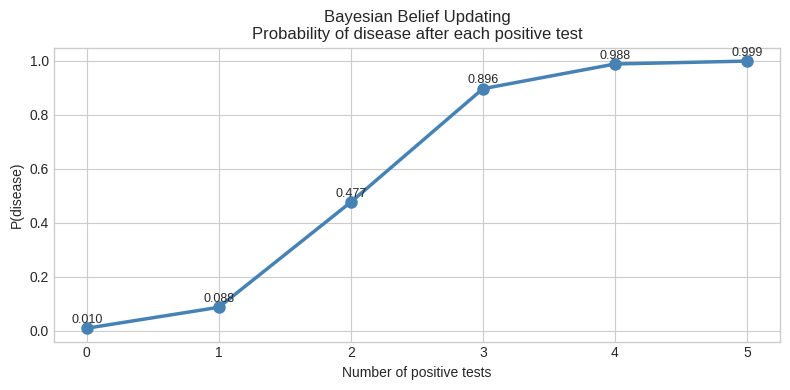

In [23]:
# Demonstrate Bayes' theorem updating beliefs
print('=== Bayesian belief updating ===')
print()

# Medical test example
# Prior: P(disease) = 0.01 (1% prevalence)
# Likelihood: P(positive test | disease) = 0.95
# Specificity: P(negative test | no disease) = 0.90 -> P(pos | no disease) = 0.10

P_disease    = 0.01
P_no_disease = 1 - P_disease
P_pos_given_disease    = 0.95
P_pos_given_no_disease = 0.10

# P(positive test) - law of total probability
P_positive = P_pos_given_disease * P_disease + P_pos_given_no_disease * P_no_disease

# Bayes: P(disease | positive) = P(positive | disease) * P(disease) / P(positive)
P_disease_given_positive = (P_pos_given_disease * P_disease) / P_positive

print(f'Prior P(disease) = {P_disease}')
print(f'Test sensitivity  = {P_pos_given_disease} (true positive rate)')
print(f'Test 1-specificity= {P_pos_given_no_disease} (false positive rate)')
print()
print(f'P(positive test)  = {P_positive:.4f}')
print(f'Posterior P(disease | positive test) = {P_disease_given_positive:.4f}')
print()
print('Intuition: even with a positive test, only ~8.7% chance of disease')
print('because the disease is rare (base rate = 1%)')
print('This is why understanding priors matters in ML!')

# Visualize belief updating across multiple tests
beliefs = [P_disease]
for _ in range(5):
    p = beliefs[-1]
    p_pos = P_pos_given_disease * p + P_pos_given_no_disease * (1-p)
    p_updated = P_pos_given_disease * p / p_pos
    beliefs.append(p_updated)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(beliefs)), beliefs, 'o-', color='steelblue',
        linewidth=2.5, markersize=8)
ax.set_title('Bayesian Belief Updating\nProbability of disease after each positive test')
ax.set_xlabel('Number of positive tests')
ax.set_ylabel('P(disease)')
ax.set_xticks(range(len(beliefs)))
for i, b in enumerate(beliefs):
    ax.text(i, b+0.02, f'{b:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 7. Monte Carlo Estimation and the Reparameterization Trick

### Monte Carlo Estimation

When an expectation $\mathbb{E}_{x \sim P}[f(x)]$ is intractable analytically, we approximate it by sampling:

$$\mathbb{E}_{x \sim P}[f(x)] \approx \frac{1}{N} \sum_{i=1}^N f(x^{(i)}), \quad x^{(i)} \sim P$$

By the law of large numbers, this converges to the true expectation as $N \to \infty$.

**In DL:**
- Mini-batch gradient descent is Monte Carlo estimation of the full-dataset gradient
- Dropout is a Monte Carlo estimate of an ensemble of networks
- VAE training: estimate $\mathbb{E}_{z \sim q_\phi}[\log p_\theta(x|z)]$ using a single sample

### The Reparameterization Trick

**Problem:** In a VAE, we need to backpropagate through a sampling step $z \sim q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2)$. But sampling is not differentiable — we cannot compute $\frac{\partial z}{\partial \phi}$.

**Solution:** Reparameterize the sample:

$$z = \mu + \sigma \odot \epsilon \quad \text{where} \quad \epsilon \sim \mathcal{N}(0, I)$$

Now the randomness $\epsilon$ is independent of $\phi = (\mu, \sigma)$. Gradients flow through $\mu$ and $\sigma$ via the deterministic transformation, while $\epsilon$ is just a fixed (sampled) constant.

**Mathematically:** $z$ has the same distribution $\mathcal{N}(\mu, \sigma^2)$ but is now a **differentiable function** of $\mu$ and $\sigma$:

$$\frac{\partial z}{\partial \mu} = 1 \qquad \frac{\partial z}{\partial \sigma} = \epsilon$$


=== The Reparameterization Trick ===

Goal: sample z ~ N(mu, sigma^2) in a differentiable way



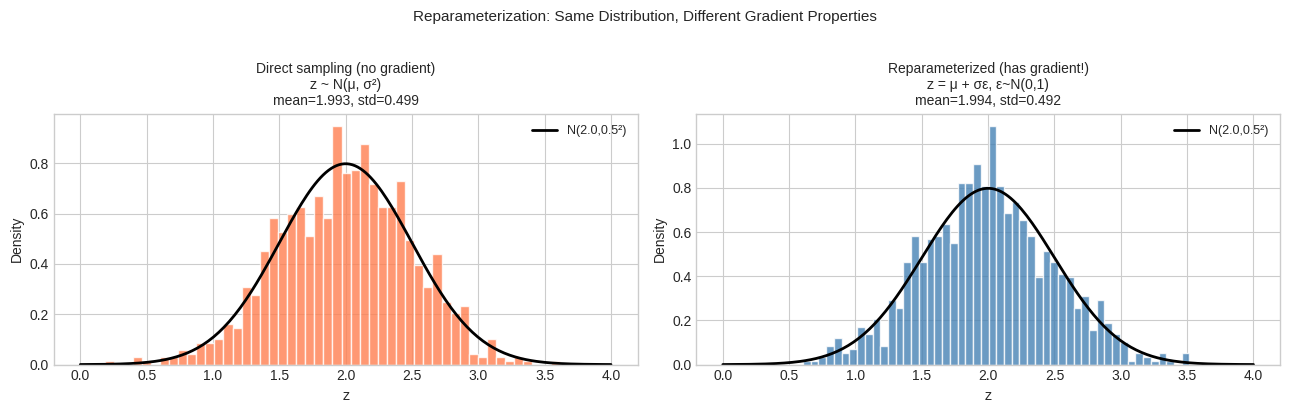

Both produce z ~ N(2.0, 0.25)
But only reparameterized version allows dL/dmu and dL/dsigma to be computed!


In [24]:
# Demonstrate the reparameterization trick
print('=== The Reparameterization Trick ===')
print()
print('Goal: sample z ~ N(mu, sigma^2) in a differentiable way')
print()

# Without reparameterization: NOT differentiable
def sample_non_reparam(mu, sigma, n=1000):
    # Sample directly — no gradient flows through this!
    return rng.normal(mu, sigma, n)

# With reparameterization: DIFFERENTIABLE
def sample_reparam(mu, sigma, n=1000):
    # Separate randomness from parameters
    epsilon = rng.normal(0, 1, n)    # fixed noise — no gradient
    return mu + sigma * epsilon      # deterministic transform of (mu, sigma)

# Verify they produce the same distribution
mu_test    = 2.0
sigma_test = 0.5

z_direct = sample_non_reparam(mu_test, sigma_test)
z_reparam = sample_reparam(mu_test, sigma_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, z, title, color in [
    (axes[0], z_direct,  'Direct sampling (no gradient)\nz ~ N(μ, σ²)', 'coral'),
    (axes[1], z_reparam, 'Reparameterized (has gradient!)\nz = μ + σε, ε~N(0,1)', 'steelblue'),
]:
    ax.hist(z, bins=50, density=True, color=color, alpha=0.8, edgecolor='white')
    x_plot = np.linspace(mu_test-4*sigma_test, mu_test+4*sigma_test, 200)
    ax.plot(x_plot, stats.norm.pdf(x_plot, mu_test, sigma_test),
            'k-', linewidth=2, label=f'N({mu_test},{sigma_test}²)')
    ax.set_title(f'{title}\nmean={z.mean():.3f}, std={z.std():.3f}', fontsize=10)
    ax.set_xlabel('z'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Reparameterization: Same Distribution, Different Gradient Properties',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('Both produce z ~ N(2.0, 0.25)')
print('But only reparameterized version allows dL/dmu and dL/dsigma to be computed!')


In [25]:
# Show reparameterization in PyTorch (the actual VAE encoder)
try:
    import torch
    import torch.nn as nn

    class VAEEncoder(nn.Module):
        def __init__(self, input_dim, latent_dim):
            super().__init__()
            self.fc_mu      = nn.Linear(input_dim, latent_dim)
            self.fc_log_var = nn.Linear(input_dim, latent_dim)

        def forward(self, x):
            mu      = self.fc_mu(x)
            log_var = self.fc_log_var(x)

            # Reparameterization trick
            epsilon = torch.randn_like(mu)          # sample noise SEPARATELY
            z       = mu + torch.exp(0.5 * log_var) * epsilon  # deterministic transform

            return z, mu, log_var

    encoder = VAEEncoder(input_dim=784, latent_dim=32)
    x_dummy = torch.randn(8, 784)  # batch of 8, MNIST-sized
    z, mu, log_var = encoder(x_dummy)

    # retain_grad so we can inspect gradients on these non-leaf tensors
    mu.retain_grad()
    log_var.retain_grad()

    print('VAE Encoder with reparameterization:')
    print(f'  Input x:      {x_dummy.shape}')
    print(f'  mu:           {mu.shape}')
    print(f'  log_var:      {log_var.shape}')
    print(f'  z (sampled):  {z.shape}')
    print(f'  z.requires_grad: {z.requires_grad}  <- gradients flow through!')

    # KL loss
    kl_loss = -0.5 * torch.mean(1 + log_var - mu**2 - torch.exp(log_var))
    print(f'\nKL loss (batch mean): {kl_loss.item():.4f}')
    kl_loss.backward()
    print(f'  mu.grad norm:      {mu.grad.norm().item():.4f}')
    print(f'  Gradients flow through reparameterization ✓')

except ImportError:
    print('PyTorch not installed — skip. See pytorch_fundamentals.ipynb for setup.')


VAE Encoder with reparameterization:
  Input x:      torch.Size([8, 784])
  mu:           torch.Size([8, 32])
  log_var:      torch.Size([8, 32])
  z (sampled):  torch.Size([8, 32])
  z.requires_grad: True  <- gradients flow through!

KL loss (batch mean): 0.2799
  mu.grad norm:      0.0369
  Gradients flow through reparameterization ✓


## 8. How Probability Shows Up in Deep Learning

A summary of every major DL concept and its probabilistic interpretation.


In [26]:
connections = {
    'Cross-entropy loss': (
        '-log P(y|x; θ)',
        'NLL under Categorical distribution = MLE for classification'
    ),
    'MSE loss': (
        '-(y-ŷ)²',
        'NLL under Gaussian noise = MLE for regression'
    ),
    'L2 regularisation': (
        'λ||W||²',
        'MAP with Gaussian prior P(W) ∝ exp(-λ||W||²)'
    ),
    'L1 regularisation': (
        'λ||W||₁',
        'MAP with Laplace prior P(W) ∝ exp(-λ||W||₁)'
    ),
    'Softmax output': (
        'exp(z_k)/Σexp(z_j)',
        'Parameterises Categorical distribution'
    ),
    'Sigmoid output': (
        '1/(1+exp(-z))',
        'Parameterises Bernoulli distribution'
    ),
    'Dropout': (
        'mask ~ Bernoulli(1-p)',
        'Approximate Bayesian inference (MC Dropout)'
    ),
    'BatchNorm': (
        '(x-μ)/σ',
        'Forces activations toward N(0,1)'
    ),
    'VAE encoder': (
        'q_φ(z|x) = N(μ_φ, σ²_φ)',
        'Variational approximation to true posterior P(z|x)'
    ),
    'VAE KL term': (
        'KL(q_φ(z|x) || N(0,I))',
        'Forces latent space to match standard normal prior'
    ),
    'GAN discriminator': (
        'D(x) = P(x is real)',
        'Estimates density ratio P_data(x)/P_gen(x)'
    ),
    'Weight init (He)': (
        'W ~ N(0, 2/n_in)',
        'Preserves activation variance = unit variance through layers'
    ),
}

print(f'{'DL Concept':<25}  {'Formula':<35}  Probabilistic Meaning')
print('=' * 100)
for concept, (formula, meaning) in connections.items():
    print(f'{concept:<25}  {formula:<35}  {meaning}')


DL Concept                 Formula                              Probabilistic Meaning
Cross-entropy loss         -log P(y|x; θ)                       NLL under Categorical distribution = MLE for classification
MSE loss                   -(y-ŷ)²                              NLL under Gaussian noise = MLE for regression
L2 regularisation          λ||W||²                              MAP with Gaussian prior P(W) ∝ exp(-λ||W||²)
L1 regularisation          λ||W||₁                              MAP with Laplace prior P(W) ∝ exp(-λ||W||₁)
Softmax output             exp(z_k)/Σexp(z_j)                   Parameterises Categorical distribution
Sigmoid output             1/(1+exp(-z))                        Parameterises Bernoulli distribution
Dropout                    mask ~ Bernoulli(1-p)                Approximate Bayesian inference (MC Dropout)
BatchNorm                  (x-μ)/σ                              Forces activations toward N(0,1)
VAE encoder                q_φ(z|x) = N(μ_φ, σ²_φ)    

## 9. Visual Intuition — Distributions in Action

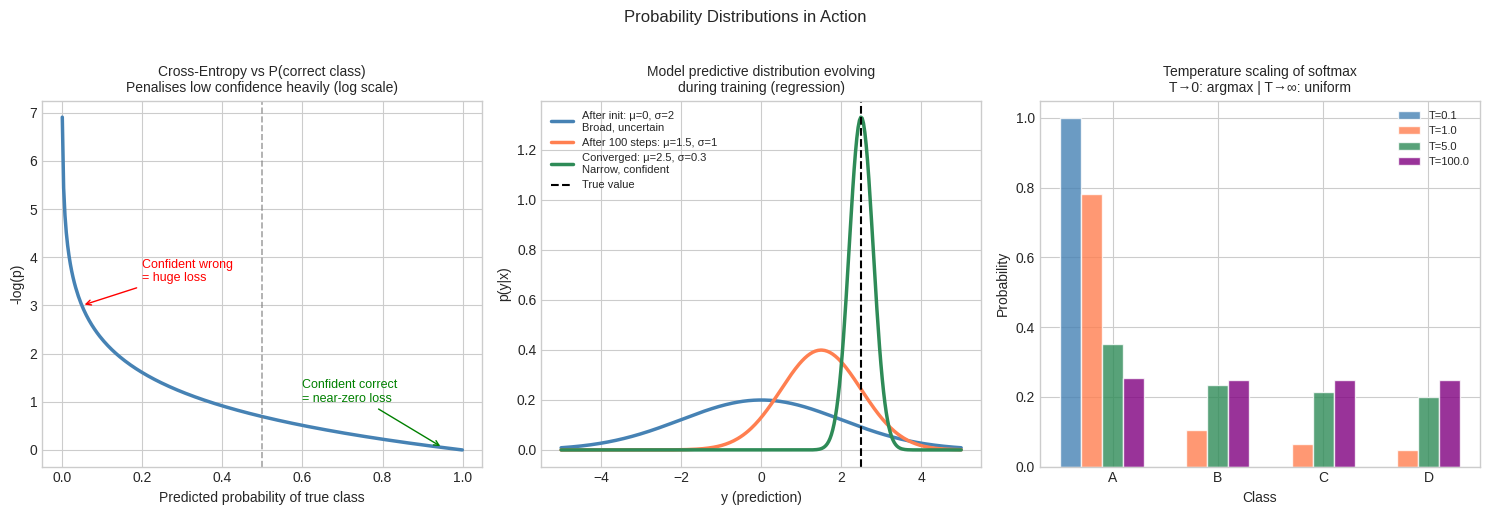

In [27]:
# Show how cross-entropy loss responds to prediction confidence
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Cross-entropy vs predicted probability for true class
p_correct = np.linspace(0.001, 0.999, 300)
ce_loss   = -np.log(p_correct)

axes[0].plot(p_correct, ce_loss, color='steelblue', linewidth=2.5)
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].set_title('Cross-Entropy vs P(correct class)\n'
                   'Penalises low confidence heavily (log scale)', fontsize=10)
axes[0].set_xlabel('Predicted probability of true class')
axes[0].set_ylabel('-log(p)')
axes[0].annotate('Confident wrong\n= huge loss', xy=(0.05, 3.0),
                 xytext=(0.2, 3.5), fontsize=9, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))
axes[0].annotate('Confident correct\n= near-zero loss', xy=(0.95, 0.05),
                 xytext=(0.6, 1.0), fontsize=9, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

# 2. How the model distribution changes during training
x_plot2 = np.linspace(-5, 5, 300)
stages  = [
    (0.0,  2.0, 'After init: μ=0, σ=2\nBroad, uncertain'),
    (1.5,  1.0, 'After 100 steps: μ=1.5, σ=1'),
    (2.5,  0.3, 'Converged: μ=2.5, σ=0.3\nNarrow, confident'),
]
colors2 = ['steelblue', 'coral', 'seagreen']
for (mu_, sig_, label), color in zip(stages, colors2):
    pdf_ = stats.norm.pdf(x_plot2, mu_, sig_)
    axes[1].plot(x_plot2, pdf_, color=color, linewidth=2.5, label=label)
axes[1].axvline(2.5, color='black', linestyle='--', linewidth=1.5, label='True value')
axes[1].set_title('Model predictive distribution evolving\nduring training (regression)',
                   fontsize=10)
axes[1].set_xlabel('y (prediction)'); axes[1].set_ylabel('p(y|x)')
axes[1].legend(fontsize=8)

# 3. Effect of temperature on softmax (sampling diversity)
logits3 = np.array([3.0, 1.0, 0.5, 0.2])
temps   = [0.1, 1.0, 5.0, 100.0]
labels3 = ['A', 'B', 'C', 'D']
x3      = np.arange(4)
width   = 0.2

for i, (T, color) in enumerate(zip(temps, ['steelblue','coral','seagreen','purple'])):
    probs3 = np.exp(logits3 / T) / np.exp(logits3 / T).sum()
    axes[2].bar(x3 + i*width, probs3, width, label=f'T={T}',
                color=color, alpha=0.8, edgecolor='white')
axes[2].set_xticks(x3 + 2*width); axes[2].set_xticklabels(labels3)
axes[2].set_title('Temperature scaling of softmax\nT→0: argmax | T→∞: uniform', fontsize=10)
axes[2].set_xlabel('Class'); axes[2].set_ylabel('Probability')
axes[2].legend(fontsize=8)

plt.suptitle('Probability Distributions in Action', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 10. Exercises

**Exercise 1:** Derive the NLL loss for a **Laplace distribution** assumption on regression residuals:

$$p(y \mid x; \theta) = \frac{1}{2b} \exp\left(-\frac{|y - f_\theta(x)|}{b}\right)$$

Show that minimising the NLL under this assumption is equivalent to minimising **MAE** (Mean Absolute Error). Then implement both MSE and MAE training on a dataset with outliers and compare robustness.


In [28]:
# Your code here


Laplace NLL derivation:
  log p(y|x;θ) = -log(2b) - |y - f(x)| / b
  -NLL = (1/m) Σ |y_i - f(x_i)| / b + log(2b)
  argmin_{θ} NLL = argmin_{θ} Σ |y_i - f(x_i)| = MAE

MSE = MLE under Gaussian noise (penalises outliers quadratically)
MAE = MLE under Laplace noise (penalises outliers linearly -> more robust)


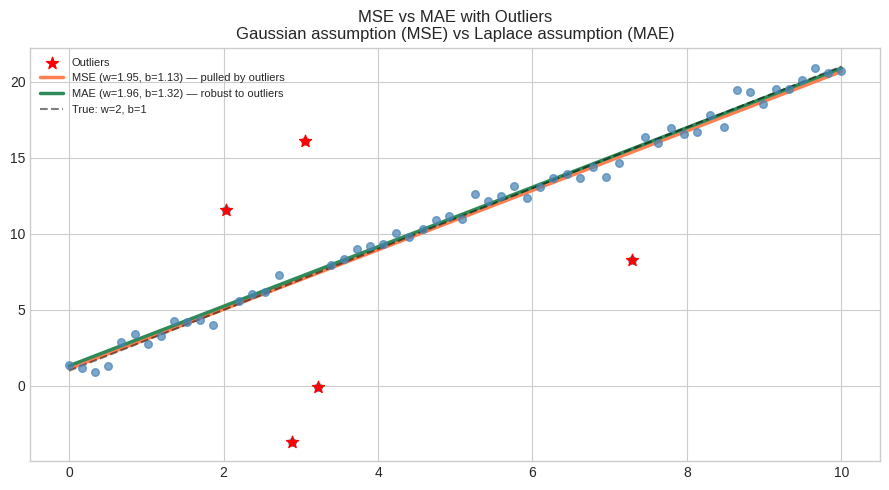

In [29]:
# Solution — derivation
print('Laplace NLL derivation:')
print('  log p(y|x;θ) = -log(2b) - |y - f(x)| / b')
print('  -NLL = (1/m) Σ |y_i - f(x_i)| / b + log(2b)')
print('  argmin_{θ} NLL = argmin_{θ} Σ |y_i - f(x_i)| = MAE')
print()
print('MSE = MLE under Gaussian noise (penalises outliers quadratically)')
print('MAE = MLE under Laplace noise (penalises outliers linearly -> more robust)')

# Experiment: regression with outliers
np.random.seed(0)
x_ex1 = np.linspace(0, 10, 60)
y_ex1 = 2 * x_ex1 + 1 + rng.normal(0, 0.5, 60)
# Add 5 outliers
outlier_idx = rng.choice(60, 5, replace=False)
y_ex1[outlier_idx] += rng.choice([-1,1], 5) * rng.uniform(5, 10, 5)

# Fit with MSE and MAE
from scipy.optimize import minimize

def fit(x, y, loss_type):
    def loss(params):
        w, b = params
        pred = w*x + b
        if loss_type == 'mse': return np.mean((y-pred)**2)
        return np.mean(np.abs(y-pred))
    return minimize(loss, [1.0, 0.0]).x

w_mse, b_mse = fit(x_ex1, y_ex1, 'mse')
w_mae, b_mae = fit(x_ex1, y_ex1, 'mae')

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x_ex1, y_ex1, color='steelblue', s=30, alpha=0.7, zorder=3)
ax.scatter(x_ex1[outlier_idx], y_ex1[outlier_idx], color='red',
           s=80, marker='*', zorder=4, label='Outliers')
ax.plot(x_ex1, w_mse*x_ex1+b_mse, color='coral',   linewidth=2.5,
        label=f'MSE (w={w_mse:.2f}, b={b_mse:.2f}) — pulled by outliers')
ax.plot(x_ex1, w_mae*x_ex1+b_mae, color='seagreen', linewidth=2.5,
        label=f'MAE (w={w_mae:.2f}, b={b_mae:.2f}) — robust to outliers')
ax.plot(x_ex1, 2*x_ex1+1, 'k--', linewidth=1.5, alpha=0.5, label='True: w=2, b=1')
ax.set_title('MSE vs MAE with Outliers\nGaussian assumption (MSE) vs Laplace assumption (MAE)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Exercise 2:** Implement the **ELBO loss** for a VAE from scratch in NumPy:

$$\mathcal{L}_{\text{ELBO}} = \underbrace{\mathbb{E}_{z\sim q_\phi}[\log p_\theta(x|z)]}_{\text{reconstruction}} - \underbrace{D_{\text{KL}}(q_\phi(z|x) \| p(z))}_{\text{regularisation}}$$

For a Gaussian VAE:
- Reconstruction term: $-\frac{1}{2}||x - \hat{x}||^2$ (MSE, assuming Gaussian decoder)
- KL term (closed form): $-\frac{1}{2}\sum_j(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2)$

Verify that the KL term is zero when $\mu=0$ and $\sigma=1$.


In [30]:
# Your code here


In [31]:
# Solution
def vae_elbo_loss(x, x_hat, mu, log_var, beta=1.0):
    # Reconstruction: -E[log p(x|z)] approximated as MSE
    recon = 0.5 * np.mean((x - x_hat)**2, axis=-1).mean()

    # KL: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl = -0.5 * np.mean(1 + log_var - mu**2 - np.exp(log_var), axis=-1).mean()

    # Total ELBO = reconstruction + beta * KL
    elbo = recon + beta * kl
    return elbo, recon, kl

# Test cases
batch, latent = 8, 16
np.random.seed(0)

x_in    = rng.normal(0, 1, (batch, 784))
x_hat_g = rng.normal(0, 1, (batch, 784))

# Case 1: perfect posterior matches prior (mu=0, sigma=1)
mu_perfect  = np.zeros((batch, latent))
lv_perfect  = np.zeros((batch, latent))  # log_var=0 -> sigma=1
elbo_p, r_p, kl_p = vae_elbo_loss(x_in, x_hat_g, mu_perfect, lv_perfect)
print(f'Case 1 (μ=0, σ=1 = prior): KL={kl_p:.6f}  (should be 0)')

# Case 2: posterior far from prior
mu_far  = rng.normal(3, 1, (batch, latent))
lv_far  = rng.normal(1, 0.5, (batch, latent))
elbo_f, r_f, kl_f = vae_elbo_loss(x_in, x_hat_g, mu_far, lv_far)
print(f'Case 2 (μ≠0, σ≠1):          KL={kl_f:.4f}  (positive penalty)')

print(f'\nELBO = Reconstruction + KL')
print(f'  Case 1: {elbo_p:.4f} = {r_p:.4f} + {kl_p:.6f}')
print(f'  Case 2: {elbo_f:.4f} = {r_f:.4f} + {kl_f:.4f}')


Case 1 (μ=0, σ=1 = prior): KL=-0.000000  (should be 0)
Case 2 (μ≠0, σ≠1):          KL=5.3157  (positive penalty)

ELBO = Reconstruction + KL
  Case 1: 1.0147 = 1.0147 + -0.000000
  Case 2: 6.3304 = 1.0147 + 5.3157


**Exercise 3:** Implement **temperature sampling** for a language model. Given a probability distribution over a vocabulary, show how temperature $T$ controls the diversity of generated text:

$$p_T(k) = \frac{\exp(\log p_k / T)}{\sum_j \exp(\log p_j / T)}$$

For $T \to 0$: always pick the most likely token (greedy). For $T = 1$: sample from the original distribution. For $T \to \infty$: uniform sampling (maximum diversity).

Simulate 1000 samples at temperatures [0.1, 0.5, 1.0, 2.0] and plot the resulting distributions.


In [32]:
# Your code here


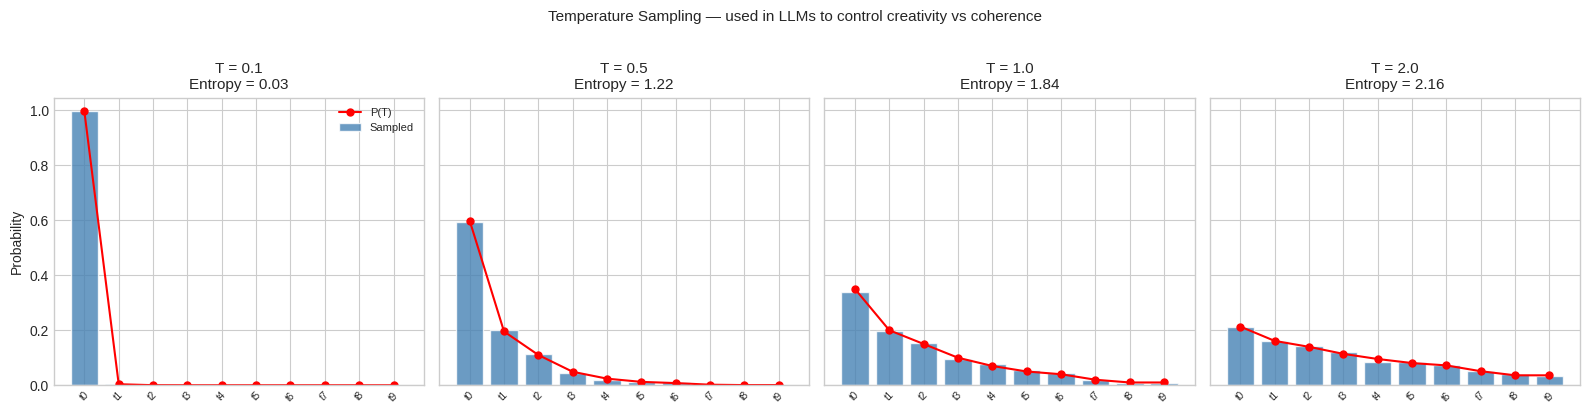

T=0.1: near-greedy, always picks tok_0 (low entropy = repetitive)
T=1.0: original distribution (balanced)
T=2.0: more uniform, diverse but less coherent (high entropy = random)

LLMs use T in [0.7, 1.3] for natural-sounding generation


In [33]:
# Solution
def temperature_sample(log_probs, temperature, n_samples=1000):
    scaled_log_probs = log_probs / temperature
    # Numerical stability
    scaled_log_probs -= scaled_log_probs.max()
    probs = np.exp(scaled_log_probs)
    probs /= probs.sum()
    return rng.choice(len(probs), size=n_samples, p=probs), probs

# Vocabulary of 10 tokens with original distribution
vocab   = [f'tok_{i}' for i in range(10)]
orig_probs = np.array([0.35, 0.20, 0.15, 0.10, 0.07, 0.05, 0.04, 0.02, 0.01, 0.01])
log_probs  = np.log(orig_probs)

temps = [0.1, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, T in zip(axes, temps):
    samples, adjusted_probs = temperature_sample(log_probs, T, n_samples=5000)
    counts = np.bincount(samples, minlength=10) / 5000
    entropy_T = -np.sum(adjusted_probs * np.log(adjusted_probs + 1e-12))

    ax.bar(range(10), counts, color='steelblue', alpha=0.8, edgecolor='white', label='Sampled')
    ax.plot(range(10), adjusted_probs, 'ro-', markersize=5, linewidth=1.5, label='P(T)')
    ax.set_title(f'T = {T}\nEntropy = {entropy_T:.2f}', fontsize=11)
    ax.set_xticks(range(10))
    ax.set_xticklabels([f't{i}' for i in range(10)], fontsize=7, rotation=45)
    if ax == axes[0]:
        ax.set_ylabel('Probability')
        ax.legend(fontsize=8)

plt.suptitle('Temperature Sampling — used in LLMs to control creativity vs coherence',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('T=0.1: near-greedy, always picks tok_0 (low entropy = repetitive)')
print('T=1.0: original distribution (balanced)')
print('T=2.0: more uniform, diverse but less coherent (high entropy = random)')
print('\nLLMs use T in [0.7, 1.3] for natural-sounding generation')


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
